In [1]:
# import regressor
import pandas as pd
import numpy as np
import sys
import math
import matplotlib.pyplot as plt

# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import SimpleRNN, Dense

# !{sys.executable} -m pip install xgboost lightgbm tensorflow

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df_14_1 = pd.read_csv('/content/drive/MyDrive/Belajar (PTA TA)/vehicle_logs_tread_14_1.csv')
df_14_2 = pd.read_csv('/content/drive/MyDrive/Belajar (PTA TA)/vehicle_logs_tread_14_2.csv')
df_21 = pd.read_csv('/content/drive/MyDrive/Belajar (PTA TA)/vehicle_logs_tread_21.csv')
df_24_1 = pd.read_csv('/content/drive/MyDrive/Belajar (PTA TA)/vehicle_logs_tread_24_1.csv')
df_24_2 = pd.read_csv('/content/drive/MyDrive/Belajar (PTA TA)/vehicle_logs_tread_24_2.csv')

In [3]:
common_features = ['sum_distance_traveled_m', 'distance_traveled_m', 'elevation_traveled_m', 'speed', 'engine_load']

def fixing(df):
    df_fr = df[common_features + ['fr_temp', 'fr_pressure', 'tr_fr']].copy()
    df_fr.rename(columns={'fr_temp': 'temp', 'fr_pressure': 'pressure', 'tr_fr': 'tr'}, inplace=True)
    df_fr['side'] = 0
    df_fl = df[common_features + ['fl_temp', 'fl_pressure', 'tr_fl']].copy()
    df_fl.rename(columns={'fl_temp': 'temp', 'fl_pressure': 'pressure', 'tr_fl': 'tr'}, inplace=True)
    df_fl['side'] = 1
    df_rr = df[common_features + ['rr_temp', 'rr_pressure', 'tr_rr']].copy()
    df_rr.rename(columns={'rr_temp': 'temp', 'rr_pressure': 'pressure', 'tr_rr': 'tr'}, inplace=True)
    df_rr['side'] = 2
    df_rl = df[common_features + ['rl_temp', 'rl_pressure', 'tr_rl']].copy()
    df_rl.rename(columns={'rl_temp': 'temp', 'rl_pressure': 'pressure', 'tr_rl': 'tr'}, inplace=True)
    df_rl['side'] = 3

    return df_fr, df_fl, df_rr, df_rl

df_14_1_fr, df_14_1_fl, df_14_1_rr, df_14_1_rl = fixing(df_14_1)
df_14_2_fl, df_14_2_fr, df_14_2_rr, df_14_2_rl = fixing(df_14_2)
df_21_fl, df_21_fr, df_21_rr, df_21_rl = fixing(df_21)
df_24_1_fl, df_24_1_fr, df_24_1_rr, df_24_1_rl = fixing(df_24_1)
df_24_2_fl, df_24_2_fr, df_24_2_rr, df_24_2_rl = fixing(df_24_2)

In [4]:
from sklearn.model_selection import train_test_split

# split datasets 70% for training and 30% for testing
def split_data(df):
    train_size = int(len(df) * 0.8)
    train_data = df[:train_size]
    test_data = df[train_size:]
    return train_data, test_data
    # return train_test_split(df, test_size=0.3, random_state=42)

datasets = [df_14_1_fr, df_14_1_fl, df_14_1_rr, df_14_1_rl,
            df_14_2_fr, df_14_2_fl, df_14_2_rr, df_14_2_rl,
            df_21_fr, df_21_fl, df_21_rr, df_21_rl,
            df_24_1_fr, df_24_1_fl, df_24_1_rr, df_24_1_rl,
            df_24_2_fr, df_24_2_fl, df_24_2_rr, df_24_2_rl]

def apply_denoising(df, window=10):
    df_denoised = df.copy()
    df_denoised = \
        df_denoised.rolling(window=window, min_periods=1).mean()
    return df_denoised

def remove_outliers(series):
    series_no_outliers = series.copy()
    Q1 = series_no_outliers.quantile(0.25)
    Q3 = series_no_outliers.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers at the bounds instead of setting to NaN
    series_no_outliers[series_no_outliers < lower_bound] = lower_bound
    series_no_outliers[series_no_outliers > upper_bound] = upper_bound
    return series_no_outliers

def remove_outliers_1(df, col='tr', limit=400, wiggle_range=(-3, 3)):
    df_no_outliers = df.copy()
    # Cap values at the limit and add a random wiggle
    df_no_outliers[col] = df_no_outliers[col].apply(lambda x: limit + np.random.uniform(wiggle_range[0], wiggle_range[1]) if x > limit else x)
    return df_no_outliers


ave = 0
for i in range(len(datasets)):
    # datasets[i].loc[:, 'tr'] = remove_outliers(datasets[i]['tr'])
    # datasets[i].loc[:, 'speed'] = remove_outliers(datasets[i]['speed'])
    # datasets[i].loc[:, 'distance_traveled_m'] = remove_outliers(datasets[i]['distance_traveled_m'])


    # datasets[i]['tr'] /= datasets[i]['distance_traveled_m']
    datasets[i]['tr'] = 6.4 / datasets[i]['tr'] / 8540000 * 40000

    # datasets[i]['tr'] *= 1e+6

    datasets[i]['lag_tr'] = datasets[i].loc[:, 'tr'].shift(1)
    datasets[i].loc[0, 'lag_tr'] = datasets[i].loc[0, 'tr']
    # datasets[i]['lag_tr2'] = datasets[i].loc[:, 'tr'].shift(2)
    # datasets[i]['lag_tr3'] = datasets[i].loc[:, 'tr'].shift(3)
    datasets[i].dropna(inplace=True)

    ave += datasets[i]['tr'].sum()

ave /= sum([len(dataset) for dataset in datasets])
print(ave)


train = []
test = []

for dataset in datasets:
    train_data, test_data = split_data(dataset)
    train.append(train_data)
    test.append(test_data)

40004.69972605305


In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_con = pd.concat([x for x in train])
train_con.reset_index(drop=True, inplace=True)
train_con_scaled = scaler.fit_transform(train_con.drop(['tr', 'sum_distance_traveled_m'], axis=1))

test_con = pd.concat([x for x in test])
test_con.reset_index(drop=True, inplace=True)
test_con_scaled = scaler.transform(test_con.drop(['tr', 'sum_distance_traveled_m'], axis=1))

In [6]:
print(train_con)

      sum_distance_traveled_m  distance_traveled_m  elevation_traveled_m  \
0                    1.548200             1.548200                   0.1   
1                    4.125716             2.577515                   0.3   
2                    6.271934             2.146218                   0.7   
3                    7.287670             1.015736                   0.9   
4                    9.109016             1.821346                   0.4   
...                       ...                  ...                   ...   
9047             30037.336400            62.106105                   2.2   
9048             30106.329562            68.993161                  -0.1   
9049             30177.808651            71.479089                   0.1   
9050             30251.143165            73.334515                  -1.1   
9051             30318.714420            67.571255                  -0.2   

      speed  engine_load  temp  pressure            tr  side        lag_tr  
0         

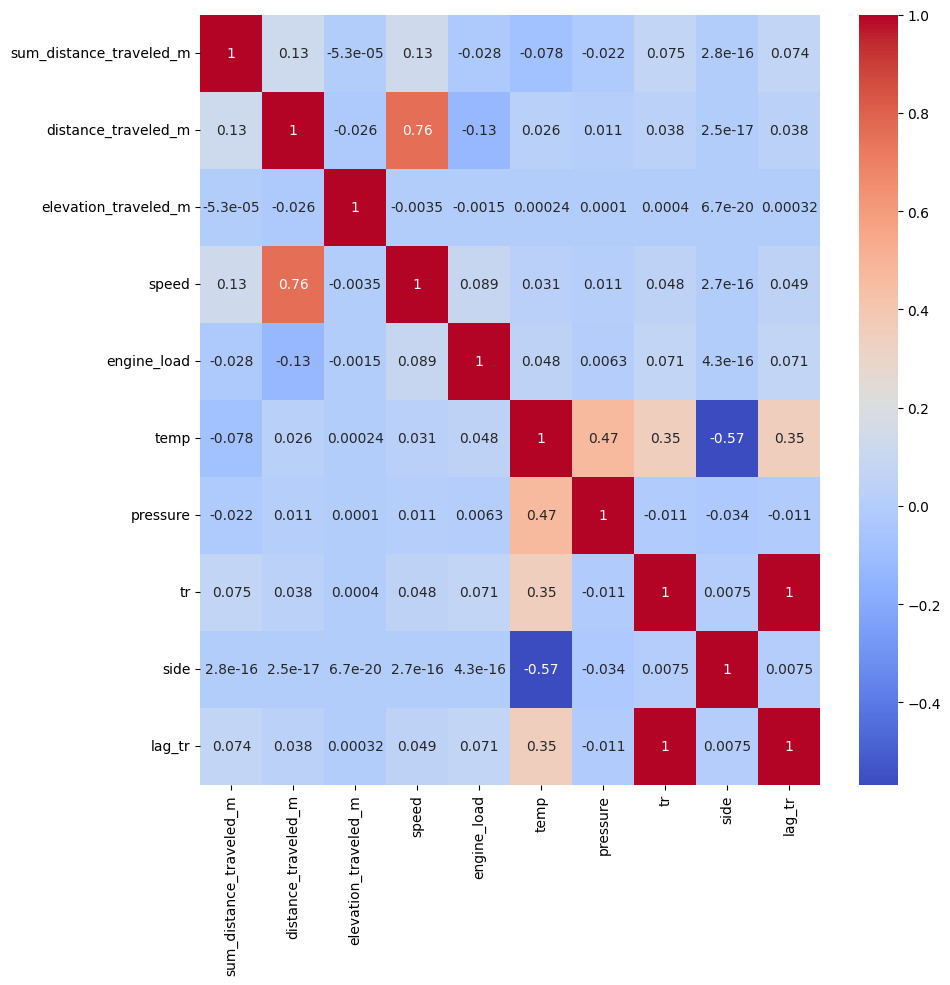

In [7]:
from matplotlib import pyplot as plt
import seaborn as sns

# heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(train_con.corr(), annot=True, cmap='coolwarm')
plt.show()

In [8]:
# mape smape mase
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error

def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs(y_pred - y_true) / ((np.abs(y_true) + np.abs(y_pred)) / 2))

def mean_absolute_scaled_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Calculate MAE of the model
    mae = np.mean(np.abs(y_pred - y_true))
    # Calculate MAE of the naive forecast (y_t = y_{t-1})
    # Ensure y_true has at least 2 elements for differencing
    if len(y_true) < 2:
        return np.nan # Or handle error appropriately
    naive_mae = np.mean(np.abs(y_true[1:] - y_true[:-1]))
    # Avoid division by zero
    if naive_mae == 0:
        return np.inf # If naive forecast has zero error, MASE is infinite if mae > 0
    return mae / naive_mae

In [9]:
remaining_useful_life = []
for dataset in datasets:
    remaining_useful_life.extend(dataset['tr'].to_list())

# remaining_useful_life = remove_outliers(pd.DataFrame(remaining_useful_life))
print(sum(remaining_useful_life) / len(remaining_useful_life))

40004.699726053055


In [10]:
def max_likelihood_estimation(dataset, max_iter = int(1e+4), tol = 1e-6):
  n = len(dataset)
  ln_x = [math.log(x) for x in dataset]
  sum_ln_x = sum(ln_x)

  k = 2

  for i in range(max_iter):
    x_k = [x ** k for x in dataset]
    x_k_ln_x = [x1 * x2 for x1, x2 in zip(x_k, ln_x)]

    sum_x_k = sum(x_k)
    sum_x_k_ln_x = sum(x_k_ln_x)

    # Ensure sum_x_k is not zero before division
    if sum_x_k == 0: # Handle cases where all values are 0, which might occur with highly processed RULs
        new_k = k # Keep k unchanged or handle as an error
    else:
        new_k = 1 / ((sum_x_k_ln_x / sum_x_k) - (sum_ln_x / n))

    if abs(new_k - k) < tol:
      k = new_k
      break
    k = new_k

  # Ensure k is not zero for the power operation
  if k == 0:
      lamb = 0 # Or handle as an error if k=0 is not expected
  else:
      lamb = (sum([x ** k for x in dataset]) / n) ** (1 / k)

  return k, lamb

# Cumulative Distribution Function
def WdistCDF(time, lamb, k):
  # Handle potential division by zero or negative base for power
  if lamb <= 0 or k == 0:
      return np.nan # Or appropriate error handling
  return 1 - math.exp(-(time / lamb) ** k)

# probability density function
def WdistPDF(time, lamb, k):
  # Handle potential division by zero or negative base for power
  if lamb <= 0 or k == 0:
      return np.nan # Or appropriate error handling
  return (k / lamb) * ((time / lamb) ** (k - 1)) * math.exp(-(time / lamb) ** k)

# getting RUL from train dataset
# train_rul = df_train_scaled.groupby('unit_number')['time_in_cycles'].transform('max')

# fitting weibull distribution
beta, eta = max_likelihood_estimation(remaining_useful_life)
print(f"k = {beta}")
print(f"\u03BB = {eta}")

k = 1.4523577688429086
λ = 44371.20294058865


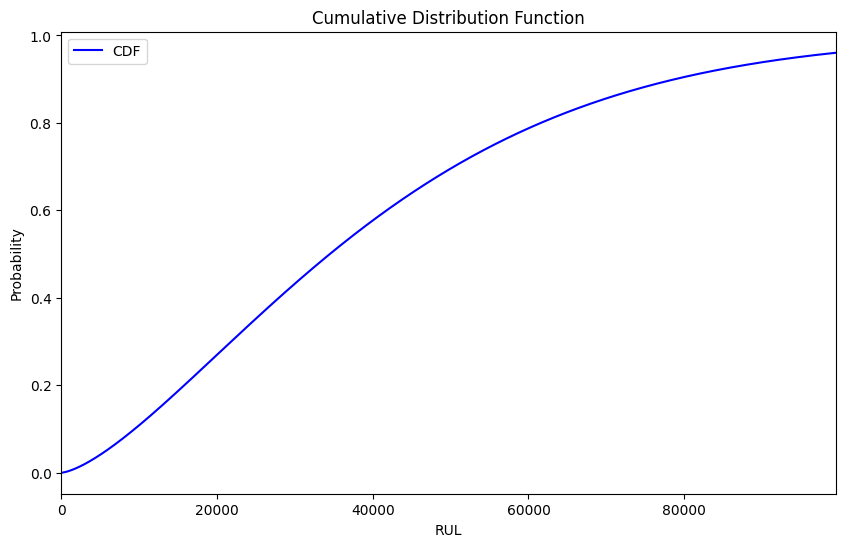

In [11]:
plt.figure(figsize=(10, 6))

# CDF
max_data = max(remaining_useful_life)
x = np.linspace(0, int(max_data), int(max_data))
plt.plot(x, [WdistCDF(val, eta, beta) for val in x], color = "blue", label = "CDF") # Changed x to val for clarity
plt.xlabel("RUL")
plt.ylabel("Probability")
plt.xlim(0, int(max_data))
plt.title("Cumulative Distribution Function")
plt.legend()

plt.show()

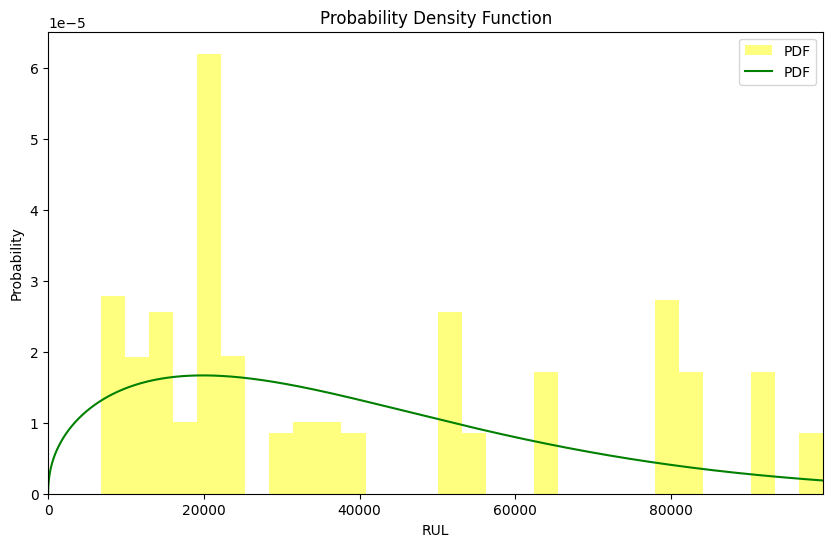

In [12]:
plt.figure(figsize=(10, 6))

# PDF and actual data distribution
max_data = max(remaining_useful_life)
plt.hist(remaining_useful_life, bins = 30, density = True, alpha = 0.5, color = "yellow", label = "PDF") # Corrected to use remaining_useful_life
x = np.linspace(0, int(max_data), int(max_data))
plt.plot(x, [WdistPDF(val, eta, beta) for val in x], color = "green", label = "PDF") # Changed x to val for clarity
plt.xlabel("RUL")
plt.ylabel("Probability")
plt.xlim(0, int(max_data))
plt.title("Probability Density Function")
plt.legend()

plt.show()

In [13]:
from scipy.special import gamma, gammaincc

def weibull_error(x, lmbda, k):
    lmbda = lmbda if lmbda > 0 else 1e-12
    s = 1.0 / k
    z = (x / lmbda) ** k

    gamma_s = gamma(s)

    l_gamma = gammaincc(s, z) * gamma_s
    l_gamma_0 = gammaincc(s, 0) * gamma_s

    result = x  + (2 * lmbda * l_gamma / k) - (lmbda * l_gamma_0 / k)
    return result

def weibull_error_2(x, lmbda, k):
    lmbda = lmbda if lmbda > 0 else 1e-12

    s = 1.0 / k
    z = (x / lmbda) ** k
    z_2 = 2 * (x / lmbda) ** k

    gamma_s = gamma(s)

    l_gamma = gammaincc(s, z) * gamma_s
    l_gamma_0 = gammaincc(s, 0) * gamma_s
    l_gamma_2 = gammaincc(s, z_2) * gamma_s

    result = x
    result -= 2 * ((lmbda * l_gamma_0 / k) - (lmbda * l_gamma / k))
    result += (lmbda * l_gamma_0 / (k * (2 ** s))) - (lmbda * l_gamma / (k * (2 ** s)))
    result += lmbda * l_gamma / (k * (2 ** s))

    return result

def left_weibull_error(x, lmbda, k):
    lmbda = lmbda if lmbda > 0 else 1e-12

    s = 1.0 / k
    z = (x / lmbda) ** k

    gamma_s = gamma(s)

    l_gamma = gammaincc(s, z) * gamma_s
    l_gamma_0 = gammaincc(s, 0) * gamma_s

    result = x + (lmbda * l_gamma / k) - (lmbda * l_gamma_0 / k)
    return result

def right_weibull_error(x, lmbda, k):
    lmbda = lmbda if lmbda > 0 else 1e-12

    s = 1.0 / k
    z = (x / lmbda) ** k

    gamma_s = gamma(s)

    l_gamma = gammaincc(s, z) * gamma_s

    result = lmbda * l_gamma / k
    return result

def mean_weibull_error(test, pred, beta):
    mwe = 0
    for t, p in zip(test, pred):
        mwe += weibull_error(t, p, beta)

    return mwe / len(test)

def quadratic_weibull_error_dataset(x_test, x_pred, k):
    sum_error = 0
    for x, lmbda in zip(x_test, x_pred):
        sum_error += weibull_error(x, lmbda, k) ** 2
    return sum_error / len(x_test)

def left_weibull_error_dataset(x_test, x_pred, k):
    sum_error = 0
    for x, lmbda in zip(x_test, x_pred):
        sum_error += left_weibull_error(x, lmbda, k)
    return sum_error / len(x_test)

def right_weibull_error_dataset(x_test, x_pred, k):
    sum_error = 0
    for x, lmbda in zip(x_test, x_pred):
        sum_error += right_weibull_error(x, lmbda, k)
    return sum_error / len(x_test)


In [14]:
def aft_ols_est(X, Y, eta):
  # no pointer
  X = X.copy()
  Y = Y.copy()

  # subtract observed RUL by weibull scale parameter
  Y = np.log(Y) - np.log(eta)

  # removing columns with very small deviation
  delete_col = []
  original_col = X.columns.tolist()
  X_col = original_col.copy()
  for col in X_col:
    if X[col].std() == 0:
      X.drop(col, axis=1, inplace=True)
      delete_col.append(col)

  # adding intercept
  X.insert(0, 'intercept', 1)

  # OLS formula
  X_T = X.T
  XTX = X_T @ X
  XTX_inv = np.linalg.inv(XTX)
  XTY = X_T @ Y


  coef_reg = XTX_inv @ XTY

  # adding back deleted columns with default value 0
  fin_coef_reg = {}

  fin_coef_reg['intercept'] = float(coef_reg[0])
  i = 0
  for col in original_col:
    if col not in delete_col:
      fin_coef_reg[col] = float(coef_reg[i := i + 1])
    else:
      fin_coef_reg[col] = 0

  return fin_coef_reg

def aft_ols(coef_reg, X_row):
  # acceleration
  phi = coef_reg.get('intercept', 0)

  for col_name, value in X_row.items(): # Iterate over Series items (index and value)
    if col_name in coef_reg: # Only include features present in coef_reg
      phi += coef_reg[col_name] * value

  return eta * math.exp(phi) # Corrected: multiply by eta

# Prepare features for OLS, scaling them as with other models
X_train_ols = pd.DataFrame(train_con_scaled, columns=train_con.drop(['tr', 'sum_distance_traveled_m'], axis=1).columns)
Y_train_ols = train_con['tr']

coef_aft_ols = aft_ols_est(X_train_ols, Y_train_ols, eta)
print(coef_aft_ols)

ols_prediction = []
X_test_ols = pd.DataFrame(scaler.transform(test_con.drop(['tr', 'sum_distance_traveled_m'], axis=1)),
                          columns=test_con.drop(['tr', 'sum_distance_traveled_m'], axis=1).columns)

for i in range(len(X_test_ols)):
    ols_prediction.append(aft_ols(coef_aft_ols, X_test_ols.iloc[i]))

{'intercept': -0.4378606728161457, 'distance_traveled_m': -0.0011682106749719273, 'elevation_traveled_m': -3.0527978735504386e-05, 'speed': -0.008409896703614422, 'engine_load': 0.0011817829434484352, 'temp': -0.1058858759274068, 'pressure': 0.03801946999354858, 'side': -0.12397218727852044, 'lag_tr': 0.796447248396327}


In [15]:
# define 3 models rnn, xgboos, lightgbm and their hyperparam
import xgboost as xgb
import lightgbm as lgb

xgboost_model = xgb.XGBRegressor()
lightgbm_model = lgb.LGBMRegressor()

xgboost_hyperparam = {
    # 1. Boosting Parameters
    # 'learning_rate': [0.01, 0.05, 0.1, 0.2],         # Step size shrinkage
    # 'n_estimators': [100, 300, 500, 1000],          # Number of boosting rounds (use with early stopping)
    # 'booster': ['gbtree'],                          # Booster type

    # 2. Tree Complexity Parameters
    'max_depth': [3, 5, 7, 10],                     # Maximum depth of a tree
    'min_child_weight': [1, 5, 10],                 # Minimum sum of instance weight (Hessian) needed in a child
    'gamma': [0.0, 0.1, 0.5, 1.0]                   # Minimum loss reduction required to make a further partition

    # 3. Sampling Parameters
    # 'subsample': [0.6, 0.8, 1.0],                   # Fraction of training instances to be sampled (rows)
    # 'colsample_bytree': [0.6, 0.8, 1.0],            # Fraction of columns to be sampled per tree

    # 4. Regularization Parameters
    # 'reg_alpha': [0, 0.001, 0.01, 0.1],             # L1 regularization term on weights
    # 'reg_lambda': [0, 0.001, 0.01, 0.1, 1.0],       # L2 regularization term on weights

    # 5. General Parameters (often fixed, but good to know)
    # 'objective': ['reg:squarederror'],
    # 'eval_metric': ['rmse']
}

lightgbm_hyperparam = {
    # 1. Boosting Parameters
    # 'learning_rate': [0.01, 0.05, 0.1, 0.2],         # Step size shrinkage
    # 'n_estimators': [100, 300, 500, 1000],          # Number of boosting rounds (use with early stopping)
    # 'boosting_type': ['gbdt'],                      # GBDT or 'dart', 'goss'

    # 2. Tree Complexity Parameters (Primary: num_leaves)
    'num_leaves': [20, 31, 50, 80],                 # Maximum number of leaves in a tree (KEY PARAMETER)
    'min_child_samples': [20, 50, 100],             # Minimum number of data points in a leaf
    'max_depth': [-1, 5, 8],                        # Maximum tree depth (-1 means no limit)

    # 3. Sampling Parameters
    # 'bagging_fraction': [0.6, 0.8, 1.0],            # Fraction of data to be used for each iteration (rows)
    # 'bagging_freq': [1],                            # Perform bagging every 'k' iterations
    # 'feature_fraction': [0.6, 0.8, 1.0],            # Fraction of features to be used for each tree (columns)

    # 4. Regularization Parameters
    # 'lambda_l1': [0, 0.001, 0.01, 0.1],             # L1 regularization term on weights
    # 'lambda_l2': [0, 0.001, 0.01, 0.1, 1.0],        # L2 regularization term on weights

    # 5. General Parameters (often fixed)
    # 'objective': ['regression'],
    # 'metric': ['r2'],

    'force_col_wise': [True]
}

xgboost_grid = GridSearchCV(xgboost_model, xgboost_hyperparam, cv=5, n_jobs=-1, verbose=2)
xgboost_grid.fit(train_con_scaled, train_con['tr'])

lightgbm_grid = GridSearchCV(lightgbm_model, lightgbm_hyperparam, cv=5, n_jobs=-1, verbose=2)
lightgbm_grid.fit(train_con_scaled, train_con['tr'])

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
[LightGBM] [Info] Total Bins 755
[LightGBM] [Info] Number of data points in the train set: 9052, number of used features: 8
[LightGBM] [Info] Start training from score 38617.738974
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


GridSearchCV(cv=5, estimator=LGBMRegressor(), n_jobs=-1,
             param_grid={'force_col_wise': [True], 'max_depth': [-1, 5, 8],
                         'min_child_samples': [20, 50, 100],
                         'num_leaves': [20, 31, 50, 80]},
             verbose=2)

In [16]:
xgboost_iterative_prediction = []

for i, test_dataset in enumerate(test):
    # Create a copy to modify without affecting original test data
    current_test_data_copy = test_dataset.copy()
    current_dataset_predictions = []

    for row_idx in range(len(current_test_data_copy)):
        # For the first row, lag_tr is already set or handled during preprocessing
        # For subsequent rows, update 'lag_tr' with the previous prediction
        if row_idx > 0:
            current_test_data_copy.loc[row_idx, 'lag_tr'] = current_dataset_predictions[-1]

        # Select features for prediction from the current row
        features_for_prediction = current_test_data_copy.iloc[[row_idx]].drop(['tr', 'sum_distance_traveled_m'], axis=1)

        # Scale the features
        scaled_features = scaler.transform(features_for_prediction)

        # Make prediction using the best estimator
        prediction = xgboost_grid.best_estimator_.predict(scaled_features)

        # Append the prediction to the current dataset's predictions list
        current_dataset_predictions.append(prediction[0])

    # Extend the overall iterative prediction list with predictions from the current dataset
    xgboost_iterative_prediction.extend(current_dataset_predictions)

print("Iterative predictions for XGBoost completed and stored in 'xgboost_iterative_prediction'.")

Iterative predictions for XGBoost completed and stored in 'xgboost_iterative_prediction'.


In [17]:
import warnings
warnings.filterwarnings('ignore')

lightgbm_iterative_prediction = []

for i, test_dataset in enumerate(test):
    # Create a copy to modify without affecting original test data
    current_test_data_copy = test_dataset.copy()
    current_dataset_predictions = []

    for row_idx in range(len(current_test_data_copy)):
        # For the first row, lag_tr is already set or handled during preprocessing
        # For subsequent rows, update 'lag_tr' with the previous prediction
        if row_idx > 0:
            current_test_data_copy.loc[row_idx, 'lag_tr'] = current_dataset_predictions[-1]

        # Select features for prediction from the current row
        features_for_prediction = current_test_data_copy.iloc[[row_idx]].drop(['tr', 'sum_distance_traveled_m'], axis=1)

        # Scale the features
        scaled_features = scaler.transform(features_for_prediction)

        # Make prediction using the best estimator
        prediction = lightgbm_grid.best_estimator_.predict(scaled_features)

        # Append the prediction to the current dataset's predictions list
        current_dataset_predictions.append(prediction[0])

    # Extend the overall iterative prediction list with predictions from the current dataset
    lightgbm_iterative_prediction.extend(current_dataset_predictions)

print("Iterative predictions for LightGBM completed and stored in 'lightgbm_iterative_prediction'.")

Iterative predictions for LightGBM completed and stored in 'lightgbm_iterative_prediction'.


In [18]:
ols_iterative_prediction = []

for i, test_dataset in enumerate(test):
    # Create a copy to modify without affecting original test data
    current_test_data_copy = test_dataset.copy()
    current_dataset_predictions = []

    for row_idx in range(len(current_test_data_copy)):
        # For subsequent rows, update 'lag_tr' with the previous prediction
        if row_idx > 0:
            current_test_data_copy.loc[row_idx, 'lag_tr'] = current_dataset_predictions[-1]

        # Select features for prediction from the current row. Exclude 'tr' and 'sum_distance_traveled_m'.
        features_for_prediction = current_test_data_copy.iloc[[row_idx]].drop(['tr', 'sum_distance_traveled_m'], axis=1)

        # Scale the features using the pre-fitted scaler
        scaled_features = pd.DataFrame(scaler.transform(features_for_prediction),
                                       columns=features_for_prediction.columns)

        # Make prediction using the aft_ols function
        prediction = aft_ols(coef_aft_ols, scaled_features.iloc[0])

        # Append the prediction to the current dataset's predictions list
        current_dataset_predictions.append(prediction)

    # Extend the overall iterative prediction list with predictions from the current dataset
    ols_iterative_prediction.extend(current_dataset_predictions)

print("Iterative predictions for AFT OLS completed and stored in 'ols_iterative_prediction'.")

Iterative predictions for AFT OLS completed and stored in 'ols_iterative_prediction'.


In [19]:
model_name_iterative = ['No Covariate', 'AFT OLS (Iterative)', 'XGBoost (Iterative)', 'LightGBM (Iterative)']
model_prediction_iterative = [
    [eta] * len(test_con),
    ols_iterative_prediction,
    xgboost_iterative_prediction,
    lightgbm_iterative_prediction
]

print("\n--- Performance Metrics (Iterative Predictions) ---")
for model, prediction_list in zip(model_name_iterative, model_prediction_iterative):
    # Ensure prediction_list is a list or numpy array for consistency
    prediction_array = np.array(prediction_list)

    print(f'\n{model}')
    # Check for empty predictions to avoid errors
    if len(prediction_array) == 0:
        print('No predictions available.')
        continue

    # Calculate metrics, handling potential division by zero for MAPE/SMAPE if y_true is zero
    mape_val = mean_absolute_percentage_error(test_con["tr"], prediction_array)
    smape_val = symmetric_mean_absolute_percentage_error(test_con["tr"], prediction_array)
    mase_val = mean_absolute_scaled_error(test_con["tr"], prediction_array)
    mwe_val = mean_weibull_error(test_con["tr"], prediction_array, beta)
    mqwe_val = quadratic_weibull_error_dataset(test_con["tr"], prediction_array, beta)
    mlwe_val = left_weibull_error_dataset(test_con["tr"], prediction_array, beta)
    mrwe_val = right_weibull_error_dataset(test_con["tr"], prediction_array, beta)

    print(f'MAPE = {mape_val:.6f}', end=' | ')
    print(f'SMAPE = {smape_val:.6f}', end=' | ')
    print(f'MASE = {mase_val:.6f}', end=' | ')
    print(f'MWE = {mwe_val:.6f}', end=' | ')
    print(f'MQWE = {mqwe_val:.6f}', end=' | ')
    print(f'MLWE = {mlwe_val:.6f}', end=' | ')
    print(f'MRWE = {mrwe_val:.6f}')



--- Performance Metrics (Iterative Predictions) ---

No Covariate
MAPE = 0.750808 | SMAPE = 0.555656 | MASE = 67.064419 | MWE = 31147.546133 | MQWE = 1089396445.584649 | MLWE = 18227.447570 | MRWE = 12920.098563

AFT OLS (Iterative)
MAPE = 0.142610 | SMAPE = 0.141886 | MASE = 18.829111 | MWE = 24918.841665 | MQWE = 906452742.243866 | MLWE = 13762.525609 | MRWE = 11156.316056

XGBoost (Iterative)
MAPE = 0.003831 | SMAPE = 0.003091 | MASE = 0.311203 | MWE = 23609.087561 | MQWE = 756935234.495038 | MLWE = 13901.889653 | MRWE = 9707.197909

LightGBM (Iterative)
MAPE = 0.002530 | SMAPE = 0.001777 | MASE = 0.216857 | MWE = 23603.939791 | MQWE = 756992033.709185 | MLWE = 13909.906166 | MRWE = 9694.033625


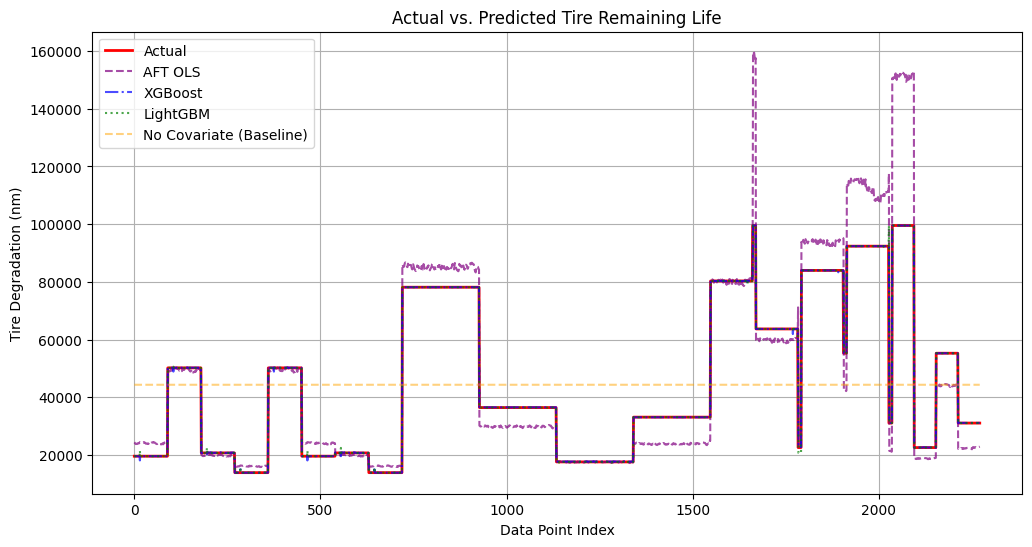

In [20]:
plt.figure(figsize=(12, 6))

# Plot Actual values
plt.plot(test_con.index, test_con['tr'], label='Actual', color='red', linewidth=2)

# Plot iterative predictions
plt.plot(test_con.index, ols_iterative_prediction, label='AFT OLS', color='purple', linestyle='--', alpha=0.7)
plt.plot(test_con.index, xgboost_iterative_prediction, label='XGBoost', color='blue', linestyle='-.', alpha=0.7)
plt.plot(test_con.index, lightgbm_iterative_prediction, label='LightGBM', color='green', linestyle=':', alpha=0.7)

# Add 'No Covariate' baseline prediction
plt.plot(test_con.index, [eta] * len(test_con), label='No Covariate (Baseline)', color='orange', linestyle='--', alpha=0.5)

plt.title('Actual vs. Predicted Tire Remaining Life')
plt.xlabel('Data Point Index')
plt.ylabel('Tire Degradation (nm)')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
import pickle

# Save xgboost_grid
with open('xgboost_grid.pkl', 'wb') as f:
    pickle.dump(xgboost_grid, f)
print("xgboost_grid saved to xgboost_grid.pkl")

# Save lightgbm_grid
with open('lightgbm_grid.pkl', 'wb') as f:
    pickle.dump(lightgbm_grid, f)
print("lightgbm_grid saved to lightgbm_grid.pkl")

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("scaler saved to scaler.pkl")

xgboost_grid saved to xgboost_grid.pkl
lightgbm_grid saved to lightgbm_grid.pkl
scaler saved to scaler.pkl
